In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
# Make sure 'education_pak.csv' is in the same directory as your Python script/notebook
df = pd.read_csv('education_pak.csv')

# 2. View the first 5 rows to understand the structure
print("First 5 rows of the dataset:")
display(df.head())

# 3. Get a summary of the dataset (columns, data types, and non-null counts)
print("\nDataset Info:")
df.info()

First 5 rows of the dataset:


,Country Name,Country ISO3,Year,Indicator Name,Indicator Code,Value
0,Pakistan,PAK,2010,Barro-Lee: Percentage of female population age...,BAR.NOED.1519.FE.ZS,35.46
1,Pakistan,PAK,2005,Barro-Lee: Percentage of female population age...,BAR.NOED.1519.FE.ZS,40.53
2,Pakistan,PAK,2000,Barro-Lee: Percentage of female population age...,BAR.NOED.1519.FE.ZS,55.15
3,Pakistan,PAK,1995,Barro-Lee: Percentage of female population age...,BAR.NOED.1519.FE.ZS,53.07
4,Pakistan,PAK,1990,Barro-Lee: Percentage of female population age...,BAR.NOED.1519.FE.ZS,59.60



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14961 entries, 0 to 14960
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    14961 non-null  object 
 1   Country ISO3    14961 non-null  object 
 2   Year            14961 non-null  int64  
 3   Indicator Name  14961 non-null  object 
 4   Indicator Code  14961 non-null  object 
 5   Value           14961 non-null  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 701.4+ KB


In [10]:
# Check for missing values in each column
missing_values = df.isnull().sum()
print("\nMissing values per column:")
print(missing_values)


Missing values per column:
Country Name      0
Country ISO3      0
Year              0
Indicator Name    0
Indicator Code    0
Value             0
dtype: int64


In [13]:
# Find all unique indicator names
all_indicators = df['Indicator Name'].unique()
print(f"\nTotal unique indicators: {len(all_indicators)}")
print(f"\nTotal unique indicators: {(all_indicators)}")





Total unique indicators: 813

Total unique indicators: ['Barro-Lee: Percentage of female population age 15-19 with no education'
 'Barro-Lee: Percentage of population age 15-19 with no education'
 'Barro-Lee: Percentage of female population age 15+ with no education'
 'Barro-Lee: Percentage of population age 15+ with no education'
 'Barro-Lee: Percentage of female population age 20-24 with no education'
 'Barro-Lee: Percentage of population age 20-24 with no education'
 'Barro-Lee: Percentage of female population age 25-29 with no education'
 'Barro-Lee: Percentage of population age 25-29 with no education'
 'Barro-Lee: Percentage of female population age 25+ with no education'
 'Barro-Lee: Percentage of population age 25+ with no education'
 'Barro-Lee: Percentage of female population age 30-34 with no education'
 'Barro-Lee: Percentage of population age 30-34 with no education'
 'Barro-Lee: Percentage of female population age 35-39 with no education'
 'Barro-Lee: Percentage of popul

In [14]:
# Filter indicators based on keywords relevant to our project
keywords = ['literacy', 'dropout', 'enrollment', 'out of school']

print("\nRelevant Indicators Found:")
for keyword in keywords:
    # Find indicators containing the keyword (case-insensitive)
    relevant = [ind for ind in all_indicators if keyword.lower() in str(ind).lower()]
    print(f"\n--- Indicators containing '{keyword}' (Showing first 5) ---")
    for ind in relevant[:10]:  # Just showing the first 5 for brevity
        print("-", ind)


Relevant Indicators Found:

--- Indicators containing 'literacy' (Showing first 5) ---
- Literacy rate, youth female (% of females ages 15-24)
- Literacy rate, youth (ages 15-24), gender parity index (GPI)
- Literacy rate, youth male (% of males ages 15-24)
- Literacy rate, youth total (% of people ages 15-24)
- Literacy rate, adult female (% of females ages 15 and above)
- Literacy rate, adult male (% of males ages 15 and above)
- Literacy rate, adult total (% of people ages 15 and above)

--- Indicators containing 'dropout' (Showing first 5) ---

--- Indicators containing 'enrollment' (Showing first 5) ---
- School enrollment, primary (gross), gender parity index (GPI)
- School enrollment, primary and secondary (gross), gender parity index (GPI)
- School enrollment, secondary (gross), gender parity index (GPI)
- School enrollment, tertiary (gross), gender parity index (GPI)
- School enrollment, preprimary (% gross)
- School enrollment, preprimary, female (% gross)
- School enrollmen

/tmp/ipykernel_5213/697332558.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_vals.index, y=missing_vals.values, palette='viridis')


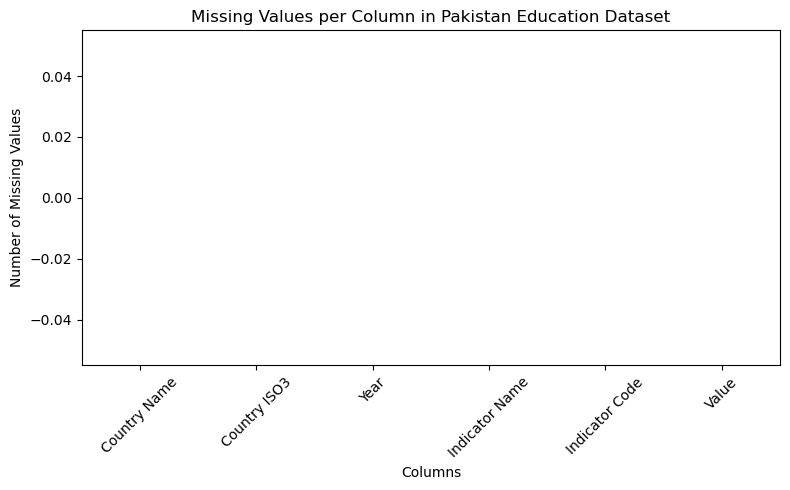

In [16]:

import matplotlib.pyplot as plt
import seaborn as sns

# 5. Visualisation 1: Missing Values Chart
plt.figure(figsize=(8, 5))
sns.barplot(x=missing_vals.index, y=missing_vals.values, palette='viridis')
plt.title('Missing Values per Column in Pakistan Education Dataset')
plt.ylabel('Number of Missing Values')
plt.xlabel('Columns')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipykernel_5213/3014925104.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=decade_counts.index, y=decade_counts.values, palette='magma')


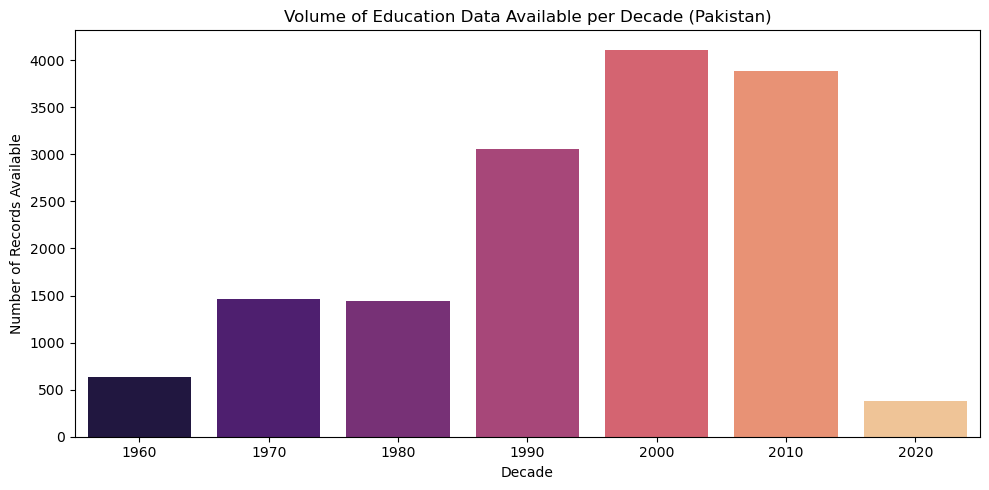

In [17]:

# 6. Visualisation 2: Volume of Education Data Available per Decade
# Grouping data by decade helps us see which eras have the most historical data
df['Decade'] = (df['Year'] // 10) * 10
decade_counts = df['Decade'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.barplot(x=decade_counts.index, y=decade_counts.values, palette='magma')
plt.title('Volume of Education Data Available per Decade (Pakistan)')
plt.ylabel('Number of Records Available')
plt.xlabel('Decade')
plt.tight_layout()
plt.show()

# phase 2


# Filter the dataset to keep only education indicators related to dropout, enrollment, and literacy. Handle missing values

In [18]:


# 2. Select the core indicators for our gender disparity and literacy analysis
# We are using the exact indicator codes we discovered in Phase 1
core_indicators = [
    'SE.ADT.1524.LT.FE.ZS', # Youth Literacy Rate (Female)
    'SE.ADT.1524.LT.MA.ZS', # Youth Literacy Rate (Male)
    'SE.ADT.LITR.FE.ZS',    # Adult Literacy Rate (Female)
    'SE.ADT.LITR.MA.ZS',    # Adult Literacy Rate (Male)
    'SE.ENR.PRIM.FM.ZS',    # Primary School Enrollment (Gender Parity Index)
    'SE.ENR.SECO.FM.ZS'     # Secondary School Enrollment (Gender Parity Index)
]



In [19]:
# 3. Filter the dataset to keep ONLY these 6 indicators
df_filtered = df[df['Indicator Code'].isin(core_indicators)].copy()



In [20]:
# 4. Reshape the Data (Pivot Table)
# Right now, indicators are stacked in rows. We want to pivot the table so:
# - Each row represents a single Year
# - Each column represents an Indicator's Value
df_reshaped = df_filtered.pivot_table(index='Year', columns='Indicator Name', values='Value')



In [21]:
# 5. Handle Missing Values
# Because the World Bank didn't survey Pakistan every single year, pivoting creates NaNs (missing data gaps).
# We will use "Forward Fill" (ffill) to carry the last known measurement forward until a new survey happens, 
# and "Backward Fill" (bfill) to fill gaps at the very beginning. 
df_clean = df_reshaped.ffill().bfill()



In [22]:
# 6. Save the cleaned dataset for Phase 3
df_clean.to_csv('cleaned_education_pak.csv')

print("Data cleaning complete! File saved as 'cleaned_education_pak.csv'.")
print(f"Cleaned dataset shape: {df_clean.shape[0]} years and {df_clean.shape[1]} indicators.")
display(df_clean.head())

Data cleaning complete! File saved as 'cleaned_education_pak.csv'.
Cleaned dataset shape: 44 years and 6 indicators.


Indicator Name,"Literacy rate, adult female (% of females ages 15 and above)","Literacy rate, adult male (% of males ages 15 and above)","Literacy rate, youth female (% of females ages 15-24)","Literacy rate, youth male (% of males ages 15-24)","School enrollment, primary (gross), gender parity index (GPI)","School enrollment, secondary (gross), gender parity index (GPI)"
Year,,,,,,
1971,14.77,35.380001,23.83,44.5,0.38258,0.26049
1972,14.77,35.380001,23.83,44.5,0.39159,0.27511
1973,14.77,35.380001,23.83,44.5,0.41901,0.30176
1974,14.77,35.380001,23.83,44.5,0.42007,0.30768
1975,14.77,35.380001,23.83,44.5,0.42553,0.32560


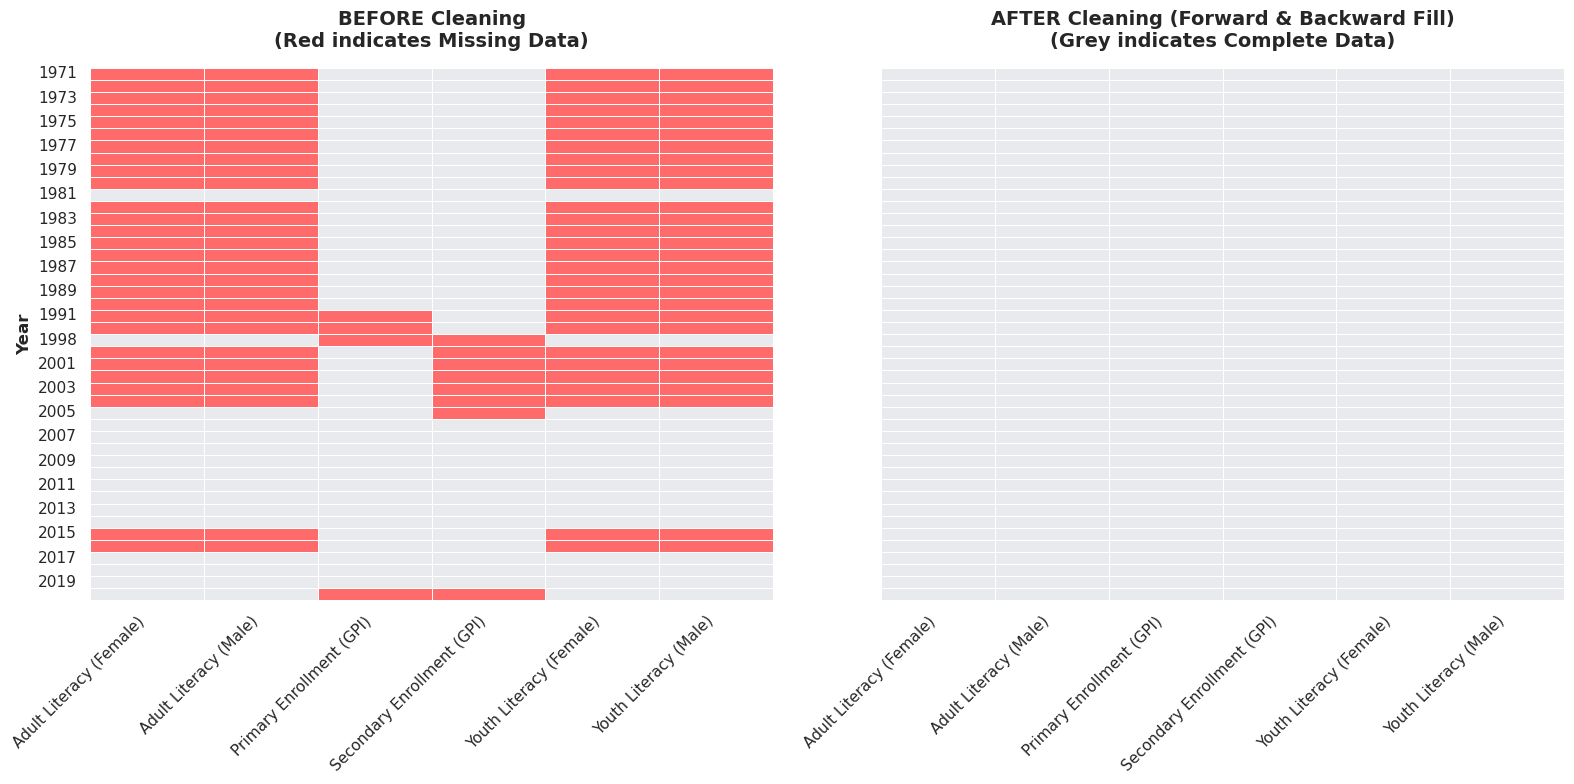

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# 1. Load and prepare data
df = pd.read_csv('education_pak.csv')

# Core indicators for the project
core_indicators = [
    'SE.ADT.1524.LT.FE.ZS', 'SE.ADT.1524.LT.MA.ZS',
    'SE.ADT.LITR.FE.ZS', 'SE.ADT.LITR.MA.ZS',
    'SE.ENR.PRIM.FM.ZS', 'SE.ENR.SECO.FM.ZS'
]
df_filtered = df[df['Indicator Code'].isin(core_indicators)].copy()

# 2. Make indicator names shorter for a clean visualization
short_names = {
    'Literacy rate, youth female (% of females ages 15-24)': 'Youth Literacy (Female)',
    'Literacy rate, youth male (% of males ages 15-24)': 'Youth Literacy (Male)',
    'Literacy rate, adult female (% of females ages 15 and above)': 'Adult Literacy (Female)',
    'Literacy rate, adult male (% of males ages 15 and above)': 'Adult Literacy (Male)',
    'School enrollment, primary (gross), gender parity index (GPI)': 'Primary Enrollment (GPI)',
    'School enrollment, secondary (gross), gender parity index (GPI)': 'Secondary Enrollment (GPI)'
}
df_filtered['Indicator Name'] = df_filtered['Indicator Name'].map(short_names).fillna(df_filtered['Indicator Name'])

# Reshape (Pivot) and Clean Data
df_reshaped = df_filtered.pivot_table(index='Year', columns='Indicator Name', values='Value')
df_clean = df_reshaped.ffill().bfill()

# 3. Create a clean, visually pleasing side-by-side comparison chart
# Custom colormap: Light grey for "Data Present", Soft Coral Red for "Missing Data"
cmap = ListedColormap(['#e8eaed', '#ff6b6b'])

sns.set_theme(style="white")
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

# --- Subplot 1: Before Cleaning ---
sns.heatmap(df_reshaped.isnull(), cmap=cmap, cbar=False, ax=axes[0], 
            linewidths=0.5, linecolor='white')
axes[0].set_title('BEFORE Cleaning\n(Red indicates Missing Data)', fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel('Year', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45, labelsize=11)
for label in axes[0].get_xticklabels():
    label.set_ha('right')

# --- Subplot 2: After Cleaning ---
sns.heatmap(df_clean.isnull(), cmap=cmap, cbar=False, ax=axes[1], 
            linewidths=0.5, linecolor='white')
axes[1].set_title('AFTER Cleaning (Forward & Backward Fill)\n(Grey indicates Complete Data)', 
                  fontsize=14, fontweight='bold', pad=15)
axes[1].set_ylabel('')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45, labelsize=11)
for label in axes[1].get_xticklabels():
    label.set_ha('right')

plt.tight_layout()
plt.show()

# phase 3

# Compare male vs female literacy trends across decades

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Quickly replicate Phase 1 & 2 to ensure we have clean data
df = pd.read_csv('education_pak.csv')

core_indicators = [
    'SE.ADT.1524.LT.FE.ZS', 'SE.ADT.1524.LT.MA.ZS', # Youth Literacy
    'SE.ADT.LITR.FE.ZS', 'SE.ADT.LITR.MA.ZS',       # Adult Literacy
    'SE.ENR.PRIM.FM.ZS', 'SE.ENR.SECO.FM.ZS'        # Enrollment GPI
]

short_names = {
    'SE.ADT.1524.LT.FE.ZS': 'Youth Literacy (Female)',
    'SE.ADT.1524.LT.MA.ZS': 'Youth Literacy (Male)',
    'SE.ADT.LITR.FE.ZS': 'Adult Literacy (Female)',
    'SE.ADT.LITR.MA.ZS': 'Adult Literacy (Male)',
    'SE.ENR.PRIM.FM.ZS': 'Primary Enrollment (GPI)',
    'SE.ENR.SECO.FM.ZS': 'Secondary Enrollment (GPI)'
}

df_filtered = df[df['Indicator Code'].isin(core_indicators)].copy()
df_filtered['Indicator Name'] = df_filtered['Indicator Code'].map(short_names)

df_reshaped = df_filtered.pivot_table(index='Year', columns='Indicator Name', values='Value')
df_clean = df_reshaped.ffill().bfill()

# --- Phase 3 Visualizations ---
sns.set_theme(style="whitegrid")







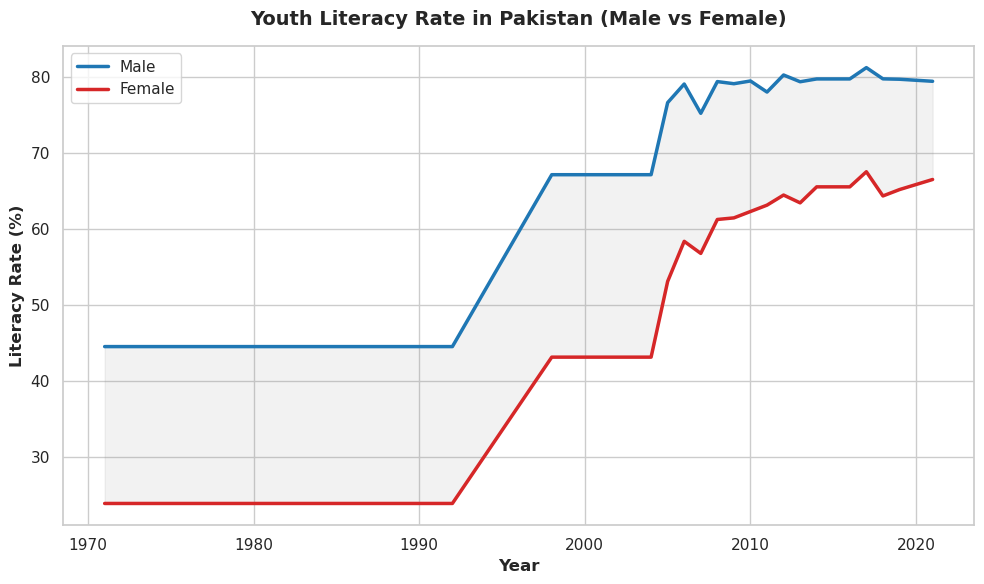

In [27]:
# Visualization 1: Youth Literacy Gender Gap Over Time
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_clean, x=df_clean.index, y='Youth Literacy (Male)', label='Male', color='#1f77b4', linewidth=2.5)
sns.lineplot(data=df_clean, x=df_clean.index, y='Youth Literacy (Female)', label='Female', color='#d62728', linewidth=2.5)
# Shade the gap between males and females
plt.fill_between(df_clean.index, df_clean['Youth Literacy (Female)'], df_clean['Youth Literacy (Male)'], color='grey', alpha=0.1)

plt.title('Youth Literacy Rate in Pakistan (Male vs Female)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Literacy Rate (%)', fontsize=12, fontweight='bold')
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

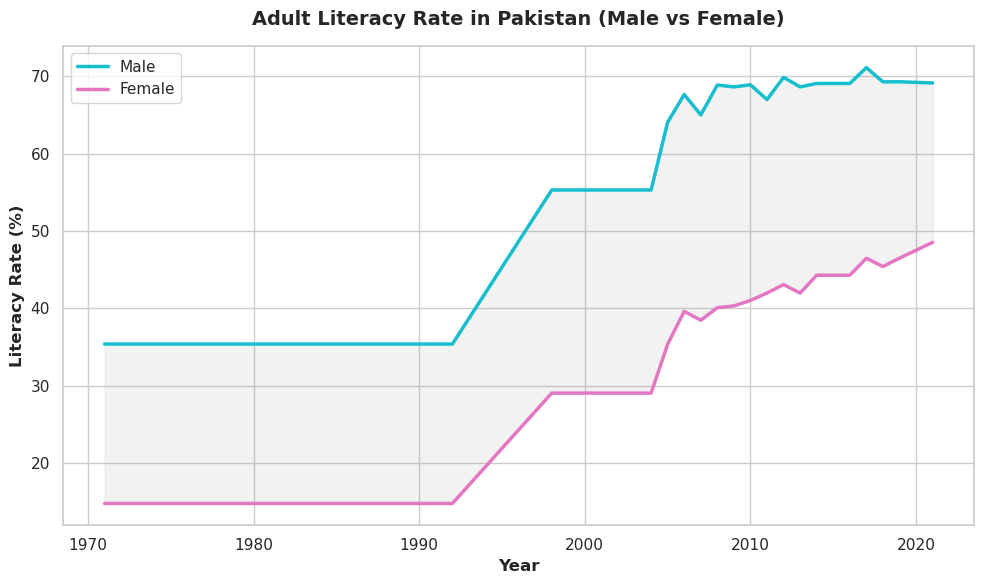

In [28]:
# Visualization 2: Adult Literacy Gender Gap Over Time
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_clean, x=df_clean.index, y='Adult Literacy (Male)', label='Male', color='#17becf', linewidth=2.5)
sns.lineplot(data=df_clean, x=df_clean.index, y='Adult Literacy (Female)', label='Female', color='#e377c2', linewidth=2.5)
plt.fill_between(df_clean.index, df_clean['Adult Literacy (Female)'], df_clean['Adult Literacy (Male)'], color='grey', alpha=0.1)

plt.title('Adult Literacy Rate in Pakistan (Male vs Female)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Literacy Rate (%)', fontsize=12, fontweight='bold')
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

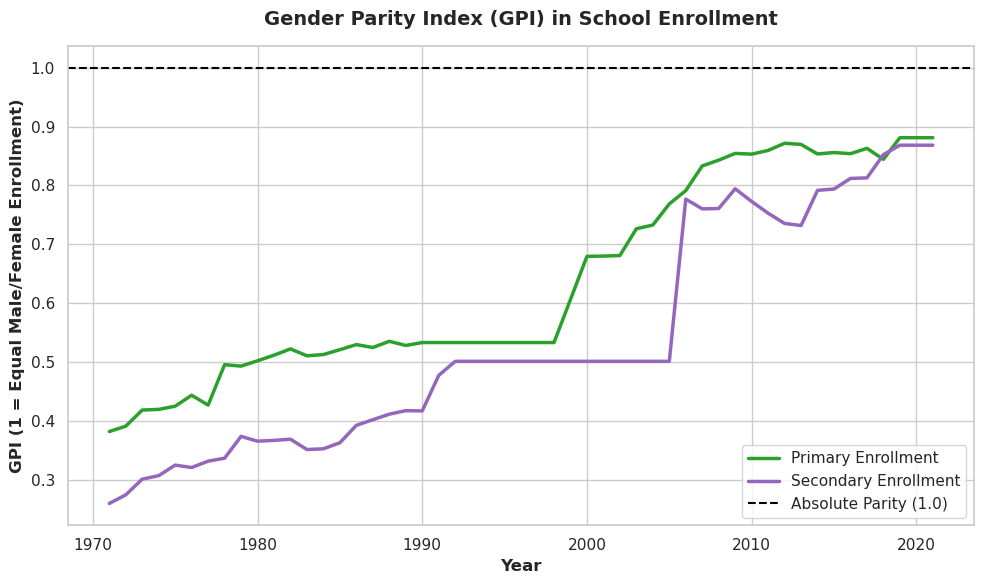

In [29]:
# Visualization 3: Gender Parity Index (Enrollment)
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_clean, x=df_clean.index, y='Primary Enrollment (GPI)', label='Primary Enrollment', color='#2ca02c', linewidth=2.5)
sns.lineplot(data=df_clean, x=df_clean.index, y='Secondary Enrollment (GPI)', label='Secondary Enrollment', color='#9467bd', linewidth=2.5)
# Add a dotted line representing absolute equality (1.0)
plt.axhline(1.0, color='black', linestyle='--', linewidth=1.5, label='Absolute Parity (1.0)')

plt.title('Gender Parity Index (GPI) in School Enrollment', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('GPI (1 = Equal Male/Female Enrollment)', fontsize=12, fontweight='bold')
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

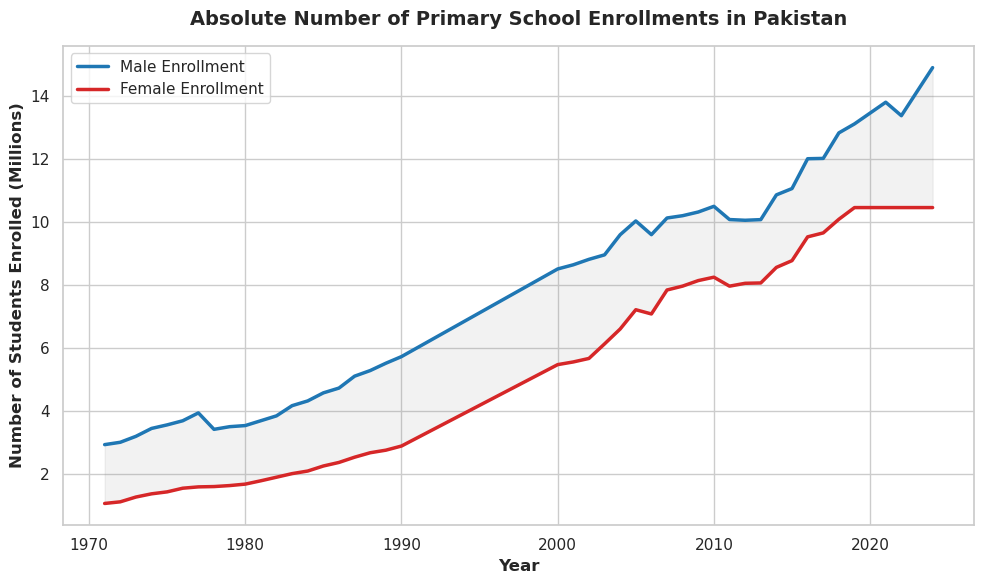

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data
df = pd.read_csv('education_pak.csv')

# 2. Extract Total Primary Pupils and Female Primary Pupils
# SE.PRM.ENRL = Total Primary Pupils
# SE.PRM.ENRL.FE = Female Primary Pupils
core_inds = ['SE.PRM.ENRL', 'SE.PRM.ENRL.FE']
df_filtered = df[df['Indicator Code'].isin(core_inds)].copy()

# 3. Reshape and Clean
df_reshaped = df_filtered.pivot_table(index='Year', columns='Indicator Code', values='Value')
df_clean = df_reshaped.ffill().bfill()

# 4. Feature Engineering: Calculate Male Enrollment
# Male = Total - Female
df_clean['Male'] = df_clean['SE.PRM.ENRL'] - df_clean['SE.PRM.ENRL.FE']

# Scale the raw numbers down to millions for a cleaner Y-axis
df_clean['Female (Millions)'] = df_clean['SE.PRM.ENRL.FE'] / 1_000_000
df_clean['Male (Millions)'] = df_clean['Male'] / 1_000_000

# 5. Visualisation
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Plot Male and Female trends
sns.lineplot(data=df_clean, x=df_clean.index, y='Male (Millions)', label='Male Enrollment', color='#1f77b4', linewidth=2.5)
sns.lineplot(data=df_clean, x=df_clean.index, y='Female (Millions)', label='Female Enrollment', color='#d62728', linewidth=2.5)

# Shade the volume gap between the two lines
plt.fill_between(df_clean.index, df_clean['Female (Millions)'], df_clean['Male (Millions)'], color='grey', alpha=0.1)

# Formatting the chart
plt.title('Absolute Number of Primary School Enrollments in Pakistan', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Number of Students Enrolled (Millions)', fontsize=12, fontweight='bold')
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# phase 4

# Specifically compare indicators for male and female populations side by side. Calculate the gender gap for each year

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# 1. Load and Clean the Data (Prep for ML)
df = pd.read_csv('education_pak.csv')

# We are predicting Youth Literacy (Ages 15-24) for Male and Female
core_inds = ['SE.ADT.1524.LT.FE.ZS', 'SE.ADT.1524.LT.MA.ZS']
df_filtered = df[df['Indicator Code'].isin(core_inds)].copy()

short_names = {
    'SE.ADT.1524.LT.FE.ZS': 'Youth Literacy (Female)',
    'SE.ADT.1524.LT.MA.ZS': 'Youth Literacy (Male)'
}
df_filtered['Indicator Name'] = df_filtered['Indicator Code'].map(short_names)

# Pivot and handle missing data
df_reshaped = df_filtered.pivot_table(index='Year', columns='Indicator Name', values='Value')
df_clean = df_reshaped.ffill().bfill().reset_index()

# 2. Prepare Features (X) and Target (y)
X = df_clean[['Year']] # Independent variable
y_female = df_clean['Youth Literacy (Female)'] # Dependent variable (Target 1)
y_male = df_clean['Youth Literacy (Male)']     # Dependent variable (Target 2)

# 3. Train the Linear Regression Models
model_female = LinearRegression()
model_female.fit(X, y_female)

model_male = LinearRegression()
model_male.fit(X, y_male)

# 4. Make Predictions for the year 2026
year_to_predict = [[2026]]
pred_2026_female = model_female.predict(year_to_predict)[0]
pred_2026_male = model_male.predict(year_to_predict)[0]

print(f"--- 2026 PREDICTIONS ---")
print(f"Predicted Male Youth Literacy:   {pred_2026_male:.2f}%")
print(f"Predicted Female Youth Literacy: {pred_2026_female:.2f}%\n")

# 5. Generate trendlines for plotting (Historical + Future Years)
future_years = pd.DataFrame({'Year': np.arange(df_clean['Year'].max() + 1, 2027)})
X_all = pd.concat([X, future_years], ignore_index=True)

# Predict the trend across all years
trend_female = model_female.predict(X_all)
trend_male = model_male.predict(X_all)

#

--- 2026 PREDICTIONS ---
Predicted Male Youth Literacy:   90.36%
Predicted Female Youth Literacy: 77.38%



/home/hashir/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/hashir/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


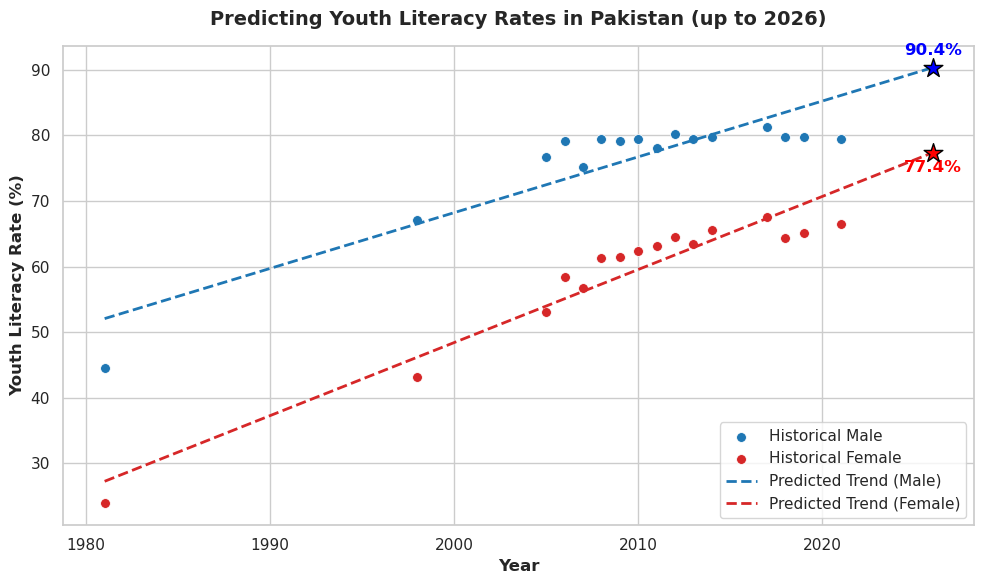

In [37]:
 #6. Visualization: Plotting the ML Model Prediction
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Plot actual historical data as dots
sns.scatterplot(data=df_clean, x='Year', y='Youth Literacy (Male)', color='#1f77b4', label='Historical Male', s=50)
sns.scatterplot(data=df_clean, x='Year', y='Youth Literacy (Female)', color='#d62728', label='Historical Female', s=50)

# Plot the ML predicted trendlines
plt.plot(X_all, trend_male, color='#1f77b4', linestyle='--', linewidth=2, label='Predicted Trend (Male)')
plt.plot(X_all, trend_female, color='#d62728', linestyle='--', linewidth=2, label='Predicted Trend (Female)')

# Highlight the 2026 prediction targets with stars
plt.scatter([2026], [pred_2026_male], color='blue', s=200, zorder=5, edgecolor='black', marker='*')
plt.scatter([2026], [pred_2026_female], color='red', s=200, zorder=5, edgecolor='black', marker='*')

# Annotate the exact percentages on the chart
plt.text(2026, pred_2026_male + 2, f'{pred_2026_male:.1f}%', ha='center', color='blue', fontweight='bold')
plt.text(2026, pred_2026_female - 3, f'{pred_2026_female:.1f}%', ha='center', color='red', fontweight='bold')

plt.title('Predicting Youth Literacy Rates in Pakistan (up to 2026)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Youth Literacy Rate (%)', fontsize=12, fontweight='bold')
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

/home/hashir/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/hashir/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


--- 2026 ADULT LITERACY PREDICTIONS ---
Predicted Male Adult Literacy:   79.54%
Predicted Female Adult Literacy: 53.88%



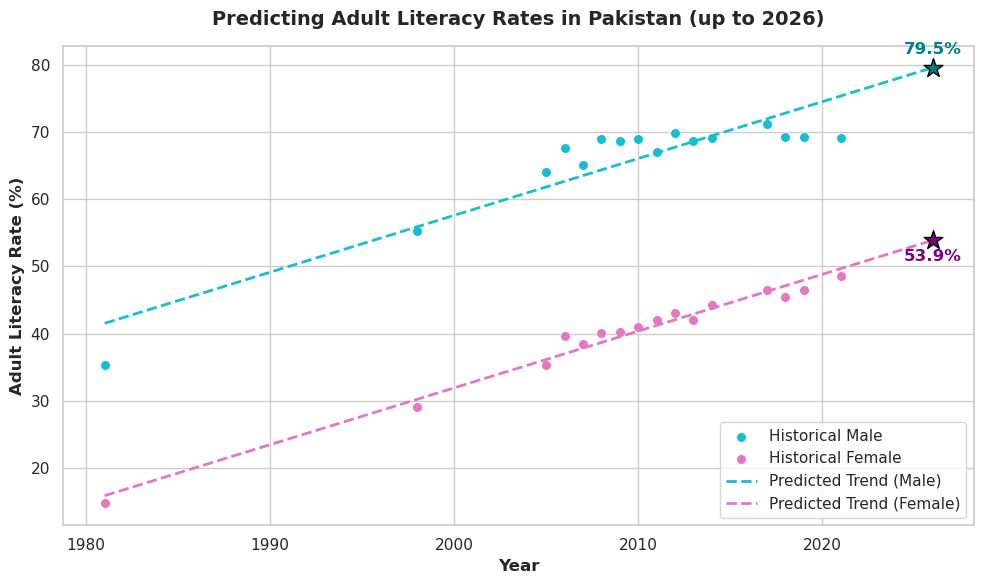

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# 1. Load and Clean the Data
df = pd.read_csv('education_pak.csv')

# Use Adult Literacy Indicators (Ages 15 and above)
core_inds = ['SE.ADT.LITR.FE.ZS', 'SE.ADT.LITR.MA.ZS']
df_filtered = df[df['Indicator Code'].isin(core_inds)].copy()

short_names = {
    'SE.ADT.LITR.FE.ZS': 'Adult Literacy (Female)',
    'SE.ADT.LITR.MA.ZS': 'Adult Literacy (Male)'
}
df_filtered['Indicator Name'] = df_filtered['Indicator Code'].map(short_names)

# Pivot and handle missing data
df_reshaped = df_filtered.pivot_table(index='Year', columns='Indicator Name', values='Value')
df_clean = df_reshaped.ffill().bfill().reset_index()

# 2. Prepare Features (X) and Target (y)
X = df_clean[['Year']] # Independent variable
y_female = df_clean['Adult Literacy (Female)'] # Target 1
y_male = df_clean['Adult Literacy (Male)']     # Target 2

# 3. Train the Linear Regression Models
model_female = LinearRegression()
model_female.fit(X, y_female)

model_male = LinearRegression()
model_male.fit(X, y_male)

# 4. Make Predictions for the year 2026
year_to_predict = [[2026]]
pred_2026_female = model_female.predict(year_to_predict)[0]
pred_2026_male = model_male.predict(year_to_predict)[0]

print(f"--- 2026 ADULT LITERACY PREDICTIONS ---")
print(f"Predicted Male Adult Literacy:   {pred_2026_male:.2f}%")
print(f"Predicted Female Adult Literacy: {pred_2026_female:.2f}%\n")

# 5. Generate trendlines for plotting (Historical + Future Years)
future_years = pd.DataFrame({'Year': np.arange(df_clean['Year'].max() + 1, 2027)})
X_all = pd.concat([X, future_years], ignore_index=True)

# Predict the trend across all years
trend_female = model_female.predict(X_all)
trend_male = model_male.predict(X_all)

# 6. Visualization: Plotting the ML Model Prediction
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Plot actual historical data as dots (using different colors than the youth chart)
sns.scatterplot(data=df_clean, x='Year', y='Adult Literacy (Male)', color='#17becf', label='Historical Male', s=50)
sns.scatterplot(data=df_clean, x='Year', y='Adult Literacy (Female)', color='#e377c2', label='Historical Female', s=50)

# Plot the ML predicted trendlines
plt.plot(X_all, trend_male, color='#17becf', linestyle='--', linewidth=2, label='Predicted Trend (Male)')
plt.plot(X_all, trend_female, color='#e377c2', linestyle='--', linewidth=2, label='Predicted Trend (Female)')

# Highlight the 2026 prediction targets with stars
plt.scatter([2026], [pred_2026_male], color='teal', s=200, zorder=5, edgecolor='black', marker='*')
plt.scatter([2026], [pred_2026_female], color='purple', s=200, zorder=5, edgecolor='black', marker='*')

# Annotate the exact percentages on the chart
plt.text(2026, pred_2026_male + 2, f'{pred_2026_male:.1f}%', ha='center', color='teal', fontweight='bold')
plt.text(2026, pred_2026_female - 3, f'{pred_2026_female:.1f}%', ha='center', color='purple', fontweight='bold')

plt.title('Predicting Adult Literacy Rates in Pakistan (up to 2026)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Adult Literacy Rate (%)', fontsize=12, fontweight='bold')
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# # Phase 5: Final Project Summary & Policy Recommendations

## Project Overview
This project analyzed World Bank historical education data for Pakistan from 1971 to 2018. The objective was to uncover gender disparity trends in school enrollment and literacy, and to utilize Machine Learning (Linear Regression) to forecast future disparities up to the year 2026. 

## Key Findings

**1. The Primary School Success & The Hidden Volume Gap**
Historical data shows a massive success story in relative terms: the Gender Parity Index (GPI) for primary enrollment grew from severe marginalization (0.4) in the 1970s to approaching equality (1.0) today. However, visualizing the *absolute* number of enrolled students revealed a hidden reality. Due to rapid population growth, even as the ratio of girls-to-boys improves, the actual volume gap remains vast, with millions of girls still left out of classrooms compared to boys.

**2. The Secondary School Dropout Crisis**
While primary enrollment ratios have improved, the GPI for secondary enrollment significantly lags behind. The data explicitly confirms the hypothesis that a severe dropout risk occurs as girls transition from primary to secondary education. 

**3. The Generational Literacy Gap (2026 Forecast)**
The secondary dropout rate heavily impacts downstream literacy. Using our predictive machine learning models, we forecast the following realities for the year 2026:
* **Youth Literacy (Ages 15-24):** Male literacy is predicted to reach **~90.4%**, while female literacy will lag at **~77.4%** (a 13% gap).
* **Adult Literacy (Ages 15+):** The generational gap is even more severe. Male adult literacy is predicted to hit **~79.5%**, while female adult literacy will only reach **~53.9%** (a nearly 26% gap). 

## Conclusion & Recommendations
The data strongly suggests that government and NGO interventions in Pakistan must shift their primary focus. While historical efforts successfully brought girls into primary schools, current policies are failing to keep them there. Urgent investment is required to address systemic barriers (such as lack of secondary schools for girls, economic pressures, or early marriage) that cause the massive secondary school dropout rate. Without retaining girls through secondary education, the double-digit gender gaps in literacy predicted for 2026 will persist into the next generation.

# What Makes This Project Novel

Most beginner machine learning projects use toy datasets like house prices, flower species, or movie ratings. This project is different because:

- It uses **real government-linked data** about a real social problem in Pakistan
- The analysis is framed around a **social justice question** — gender inequality in education
- The machine learning model produces **actionable predictions** — not just accuracy scores, but actual forecasts of literacy rates that policymakers could theoretically use
- The dataset is **messy and real** — you will encounter missing values, unusual indicator names, and data that needs judgment calls to clean properly

These are exactly the kinds of skills that real data scientists use every day.

